# Unsupervised Video Foreground Extraction with Robust PCA

This project separates a surveillance video into:

- a low-rank background;
- sparse moving foreground objects.

No foreground labels, object classes, or bounding boxes are used.

The main method is Robust Principal Component Analysis implemented through
Principal Component Pursuit.

The project evaluates:

- decomposition convergence;
- effective background rank;
- foreground sparsity;
- background stability;
- sensitivity to the regularisation parameter;
- detected motion across time;
- qualitative foreground-mask quality.

In [1]:
from pathlib import Path
from urllib.request import Request, urlopen

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Image, display
from PIL import Image as PILImage

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

VIDEO_URL = (
    "https://raw.githubusercontent.com/opencv/opencv/"
    "5.x/samples/data/vtest.avi"
)

VIDEO_PATH = Path("vtest.avi")

FRAME_WIDTH = 96
FRAME_HEIGHT = 72
MAX_FRAMES = 120
FRAME_STEP = 2

In [2]:
if not VIDEO_PATH.exists():
    request = Request(
        VIDEO_URL,
        headers={"User-Agent": "Mozilla/5.0"},
    )

    with urlopen(request, timeout=120) as response:
        VIDEO_PATH.write_bytes(response.read())

print(f"Video path: {VIDEO_PATH.resolve()}")
print(f"File size: {VIDEO_PATH.stat().st_size / 1_000_000:.2f} MB")

Video path: E:\machine-learning-lab\unsupervised_learning\vtest.avi
File size: 8.13 MB


In [3]:
capture = cv2.VideoCapture(str(VIDEO_PATH))

if not capture.isOpened():
    raise RuntimeError("OpenCV could not open the video.")

source_fps = capture.get(cv2.CAP_PROP_FPS)
source_frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
source_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
source_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

grayscale_frames = []
colour_frames = []
source_frame_indices = []

frame_index = 0

while len(grayscale_frames) < MAX_FRAMES:
    success, bgr_frame = capture.read()

    if not success:
        break

    if frame_index % FRAME_STEP == 0:
        resized = cv2.resize(
            bgr_frame,
            (FRAME_WIDTH, FRAME_HEIGHT),
            interpolation=cv2.INTER_AREA,
        )

        rgb_frame = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        gray_frame = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

        colour_frames.append(rgb_frame)
        grayscale_frames.append(gray_frame.astype(np.float64) / 255.0)
        source_frame_indices.append(frame_index)

    frame_index += 1

capture.release()

grayscale_frames = np.stack(grayscale_frames)
colour_frames = np.stack(colour_frames)
source_frame_indices = np.asarray(source_frame_indices)

video_matrix = grayscale_frames.reshape(
    len(grayscale_frames),
    -1,
).T

video_summary = pd.Series({
    "original frames": source_frame_count,
    "original resolution": f"{source_width} × {source_height}",
    "frames per second": source_fps,
    "frames retained": len(grayscale_frames),
    "frame sampling step": FRAME_STEP,
    "processed resolution": f"{FRAME_WIDTH} × {FRAME_HEIGHT}",
    "video matrix rows": video_matrix.shape[0],
    "video matrix columns": video_matrix.shape[1],
})

display(video_summary.to_frame("value"))

,value
original frames,795
original resolution,768 × 576
frames per second,10.0
frames retained,120
frame sampling step,2
processed resolution,96 × 72
video matrix rows,6912
video matrix columns,120


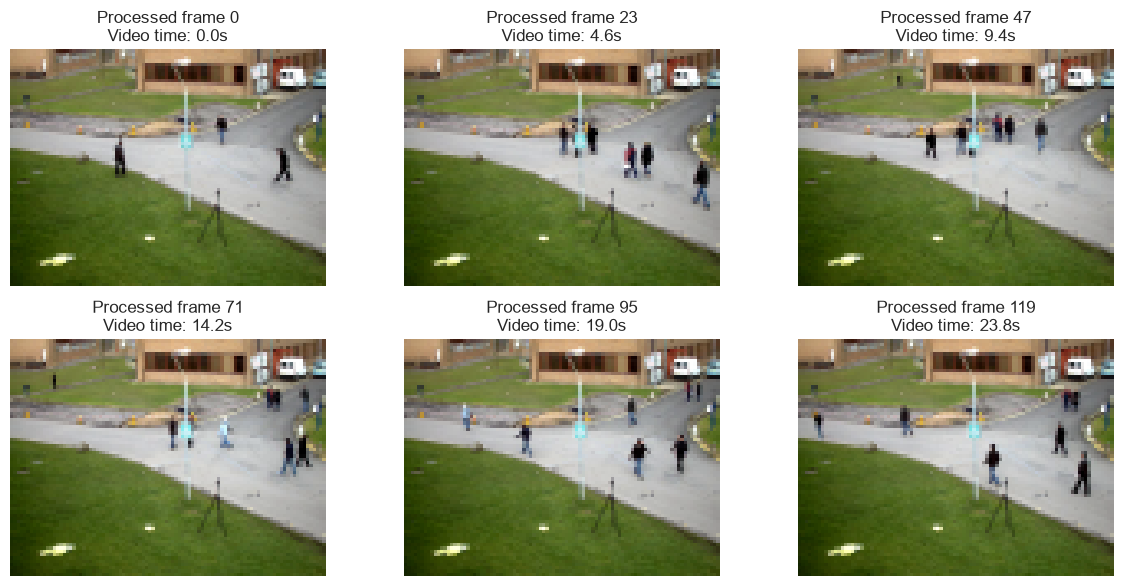

In [4]:
preview_indices = np.linspace(
    0,
    len(grayscale_frames) - 1,
    6,
    dtype=int,
)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for axis, index in zip(axes.flat, preview_indices):
    time_seconds = source_frame_indices[index] / source_fps

    axis.imshow(colour_frames[index])
    axis.set_title(
        f"Processed frame {index}\n"
        f"Video time: {time_seconds:.1f}s"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

## Video and data observations

The original video contains 795 frames at a resolution of 768 × 576 pixels and a frame rate of 10 frames per second. To keep repeated singular value decomposition computationally practical, every second frame was sampled and resized to 96 × 72 pixels. The analysis retained 120 frames, covering approximately the first 23.8 seconds of video.

After preprocessing, each frame contained 6,912 grayscale pixels. Flattening each frame into one column produced a video matrix with 6,912 rows and 120 columns.

The camera remained stationary throughout the analysed sequence. Buildings, grass, pavement, poles and other scene elements stayed in approximately the same locations, while pedestrians moved through different parts of the frame. The pedestrians occupied only a small part of each image.

These properties support the assumptions of Robust PCA:

- the stationary scene should be representable using a low-rank background;
- pedestrians should appear as sparse deviations because they occupy relatively few pixels and change position between frames.

Minor video-compression noise, changes in pedestrian overlap and small intensity variations may prevent the decomposition from being perfectly low-rank and sparse.

In [5]:
def soft_threshold(values, threshold):
    """Shrink values towards zero."""

    return (
        np.sign(values)
        * np.maximum(np.abs(values) - threshold, 0)
    )


def singular_value_threshold(matrix, threshold):
    """Apply soft thresholding to a matrix's singular values."""

    left_vectors, singular_values, right_vectors = np.linalg.svd(
        matrix,
        full_matrices=False,
    )

    retained = singular_values > threshold
    rank = int(retained.sum())

    if rank == 0:
        return np.zeros_like(matrix), 0

    reduced_values = singular_values[retained] - threshold

    reconstructed = (
        left_vectors[:, retained] * reduced_values
    ) @ right_vectors[retained]

    return reconstructed, rank

In [6]:
def robust_pca(
    matrix,
    lambda_value=None,
    tolerance=1e-6,
    max_iterations=200,
    verbose=True,
):
    rows, columns = matrix.shape

    if lambda_value is None:
        lambda_value = 1 / np.sqrt(max(rows, columns))

    spectral_norm = np.linalg.norm(matrix, 2)
    infinity_norm = np.max(np.abs(matrix)) / lambda_value
    dual_norm = max(spectral_norm, infinity_norm)

    multiplier = matrix / dual_norm

    low_rank = np.zeros_like(matrix)
    sparse = np.zeros_like(matrix)

    mu = 1.25 / spectral_norm
    maximum_mu = mu * 1e7
    mu_growth = 1.5

    matrix_norm = np.linalg.norm(matrix, ord="fro")
    history = []

    for iteration in range(1, max_iterations + 1):
        low_rank, current_rank = singular_value_threshold(
            matrix - sparse + multiplier / mu,
            1 / mu,
        )

        sparse = soft_threshold(
            matrix - low_rank + multiplier / mu,
            lambda_value / mu,
        )

        residual = matrix - low_rank - sparse

        relative_error = (
            np.linalg.norm(residual, ord="fro")
            / matrix_norm
        )

        history.append({
            "iteration": iteration,
            "relative_error": relative_error,
            "temporary_rank": current_rank,
        })

        multiplier = multiplier + mu * residual
        mu = min(mu * mu_growth, maximum_mu)

        if verbose and (
            iteration == 1
            or iteration % 10 == 0
            or relative_error < tolerance
        ):
            print(
                f"Iteration {iteration:3d} | "
                f"error={relative_error:.8f} | "
                f"rank={current_rank}"
            )

        if relative_error < tolerance:
            break

    return (
        low_rank,
        sparse,
        pd.DataFrame(history),
        lambda_value,
    )

In [7]:
low_rank_matrix, sparse_matrix, convergence_history, lambda_value = (
    robust_pca(video_matrix)
)

print(f"\nSelected lambda: {lambda_value:.6f}")
print(f"Iterations completed: {len(convergence_history)}")
print(
    "Final relative error:",
    f"{convergence_history['relative_error'].iloc[-1]:.8f}",
)

Iteration   1 | error=0.11498243 | rank=1
Iteration  10 | error=0.01081954 | rank=3
Iteration  20 | error=0.00026593 | rank=38
Iteration  30 | error=0.00000461 | rank=56
Iteration  34 | error=0.00000090 | rank=63

Selected lambda: 0.012028
Iterations completed: 34
Final relative error: 0.00000090


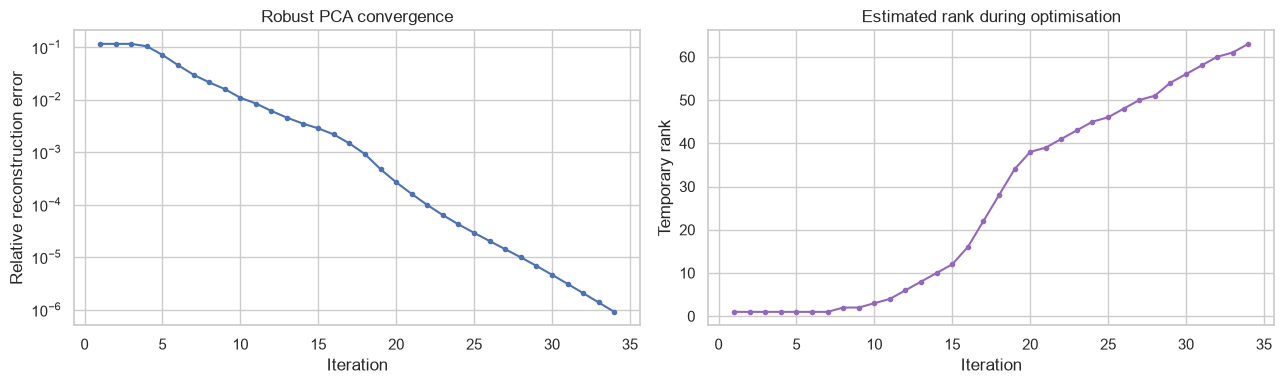

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(
    convergence_history["iteration"],
    convergence_history["relative_error"],
    marker="o",
    markersize=3,
)

axes[0].set(
    title="Robust PCA convergence",
    xlabel="Iteration",
    ylabel="Relative reconstruction error",
)

axes[1].plot(
    convergence_history["iteration"],
    convergence_history["temporary_rank"],
    marker="o",
    markersize=3,
    color="tab:purple",
)

axes[1].set(
    title="Estimated rank during optimisation",
    xlabel="Iteration",
    ylabel="Temporary rank",
)

plt.tight_layout()
plt.show()

In [9]:
background_singular_values = np.linalg.svd(
    low_rank_matrix,
    compute_uv=False,
)

effective_rank = int(
    np.sum(
        background_singular_values
        > 0.001 * background_singular_values[0]
    )
)

relative_reconstruction_error = (
    np.linalg.norm(
        video_matrix
        - low_rank_matrix
        - sparse_matrix,
        ord="fro",
    )
    / np.linalg.norm(video_matrix, ord="fro")
)

meaningful_sparse_fraction = np.mean(
    np.abs(sparse_matrix) > 0.01
)

original_temporal_variation = (
    video_matrix.std(axis=1).mean()
)

background_temporal_variation = (
    low_rank_matrix.std(axis=1).mean()
)

variation_reduction = (
    100
    * (
        original_temporal_variation
        - background_temporal_variation
    )
    / original_temporal_variation
)

decomposition_summary = pd.Series({
    "effective background rank": effective_rank,
    "number of frames": video_matrix.shape[1],
    "relative reconstruction error": relative_reconstruction_error,
    "meaningful sparse pixel fraction": meaningful_sparse_fraction,
    "original mean temporal variation": original_temporal_variation,
    "background mean temporal variation": background_temporal_variation,
    "background variation reduction percent": variation_reduction,
})

display(
    decomposition_summary
    .to_frame("value")
    .round(6)
)

,value
effective background rank,9.000000
number of frames,120.000000
relative reconstruction error,0.000001
meaningful sparse pixel fraction,0.052906
original mean temporal variation,0.031845
background mean temporal variation,0.007257
background variation reduction percent,77.210571


In [10]:
def remove_small_components(mask, minimum_area=10):
    component_count, labels, statistics, _ = (
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8,
        )
    )

    cleaned = np.zeros_like(mask)

    for component in range(1, component_count):
        area = statistics[
            component,
            cv2.CC_STAT_AREA,
        ]

        if area >= minimum_area:
            cleaned[labels == component] = 255

    return cleaned


def sparse_frame_to_mask(sparse_frame):
    maximum_value = sparse_frame.max()

    if maximum_value <= 1e-12:
        return np.zeros(
            sparse_frame.shape,
            dtype=np.uint8,
        )

    scaled = cv2.normalize(
        sparse_frame,
        None,
        0,
        255,
        cv2.NORM_MINMAX,
    ).astype(np.uint8)

    _, mask = cv2.threshold(
        scaled,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )

    kernel = np.ones((3, 3), dtype=np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel,
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel,
    )

    return remove_small_components(
        mask,
        minimum_area=10,
    )


sparse_strength_frames = (
    np.abs(sparse_matrix)
    .T
    .reshape(
        len(grayscale_frames),
        FRAME_HEIGHT,
        FRAME_WIDTH,
    )
)

background_frames = (
    low_rank_matrix
    .T
    .reshape(
        len(grayscale_frames),
        FRAME_HEIGHT,
        FRAME_WIDTH,
    )
)

foreground_masks = np.stack([
    sparse_frame_to_mask(frame)
    for frame in sparse_strength_frames
])

print("Foreground masks:", foreground_masks.shape)

Foreground masks: (120, 72, 96)


In [11]:
motion_strength = np.mean(
    sparse_strength_frames,
    axis=(1, 2),
)

candidate_order = np.argsort(motion_strength)[::-1]
selected_frames = []

for candidate in candidate_order:
    sufficiently_separated = all(
        abs(candidate - existing) >= 12
        for existing in selected_frames
    )

    if sufficiently_separated:
        selected_frames.append(int(candidate))

    if len(selected_frames) == 4:
        break

selected_frames = sorted(selected_frames)

activity_table = pd.DataFrame({
    "processed_frame": selected_frames,
    "source_frame": source_frame_indices[selected_frames],
    "video_time_seconds": (
        source_frame_indices[selected_frames]
        / source_fps
    ),
    "motion_strength": motion_strength[selected_frames],
})

display(activity_table.round(4))

,processed_frame,source_frame,video_time_seconds,motion_strength
0,9,18,1.8,0.0122
1,23,46,4.6,0.0119
2,102,204,20.4,0.0114
3,119,238,23.8,0.0140


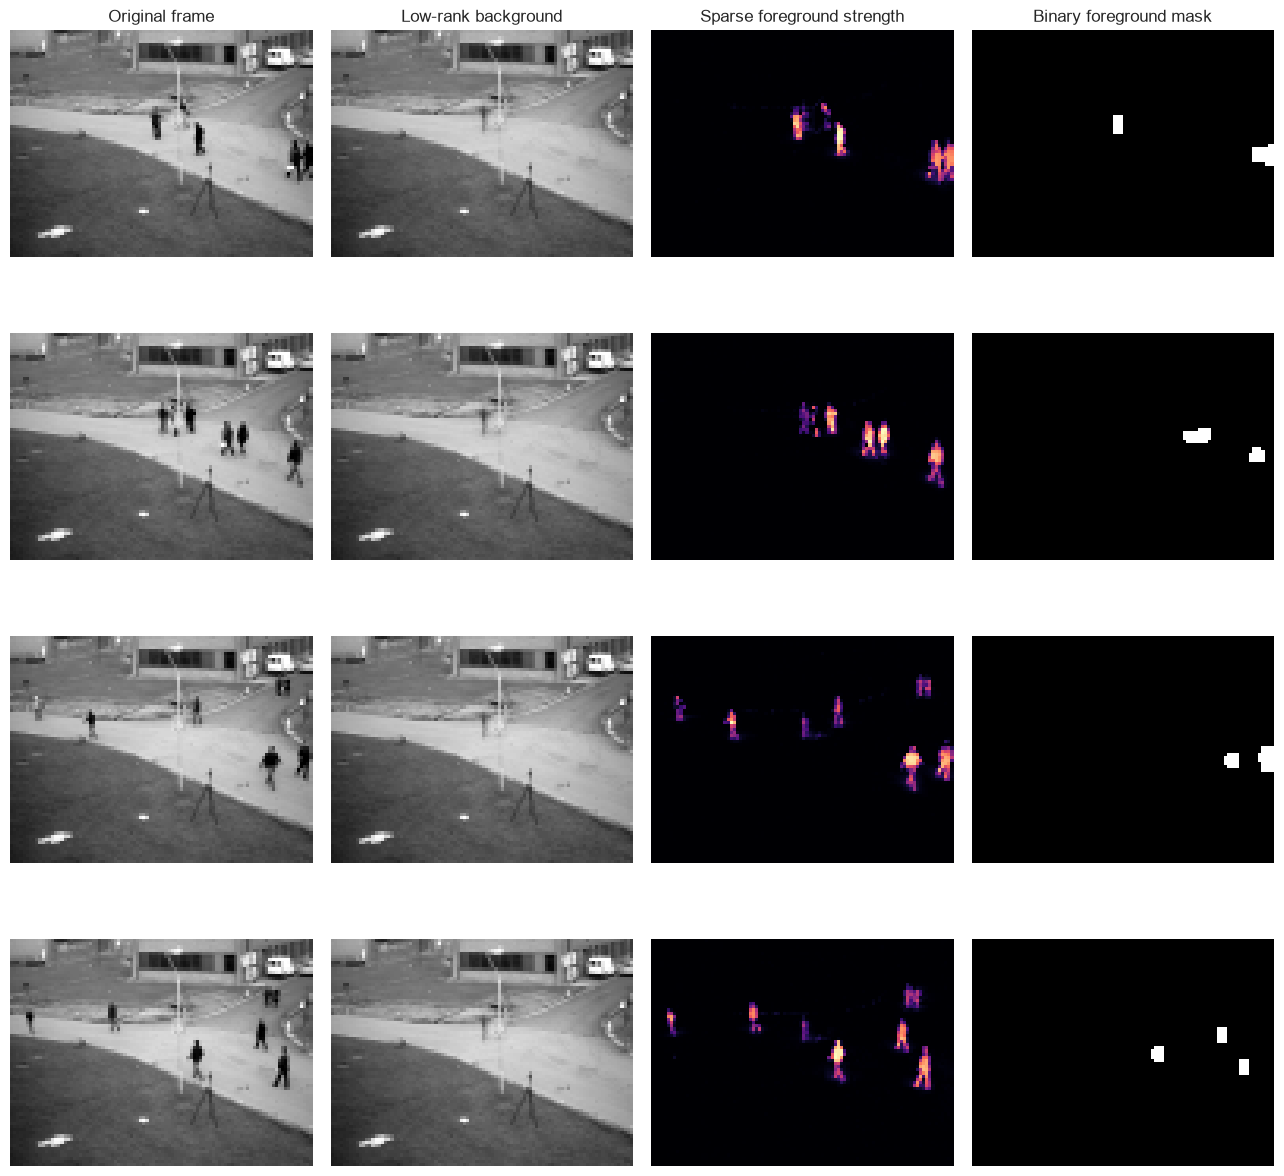

In [12]:
fig, axes = plt.subplots(
    len(selected_frames),
    4,
    figsize=(13, 3.2 * len(selected_frames)),
)

for row, frame_index in enumerate(selected_frames):
    axes[row, 0].imshow(
        grayscale_frames[frame_index],
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[row, 1].imshow(
        np.clip(
            background_frames[frame_index],
            0,
            1,
        ),
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[row, 2].imshow(
        sparse_strength_frames[frame_index],
        cmap="magma",
    )

    axes[row, 3].imshow(
        foreground_masks[frame_index],
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[row, 0].set_ylabel(
        f"Frame {frame_index}",
        fontsize=11,
    )

    for column in range(4):
        axes[row, column].axis("off")

column_titles = [
    "Original frame",
    "Low-rank background",
    "Sparse foreground strength",
    "Binary foreground mask",
]

for column, title in enumerate(column_titles):
    axes[0, column].set_title(title)

plt.tight_layout()
plt.show()

In [13]:
foreground_fraction = (
    foreground_masks > 0
).mean(axis=(1, 2))

component_counts = []

for mask in foreground_masks:
    component_count, _, statistics, _ = (
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8,
        )
    )

    valid_components = 0

    for component in range(1, component_count):
        area = statistics[
            component,
            cv2.CC_STAT_AREA,
        ]

        if area >= 10:
            valid_components += 1

    component_counts.append(valid_components)

motion_df = pd.DataFrame({
    "processed_frame": np.arange(len(grayscale_frames)),
    "source_frame": source_frame_indices,
    "video_time_seconds": source_frame_indices / source_fps,
    "motion_strength": motion_strength,
    "foreground_fraction": foreground_fraction,
    "detected_components": component_counts,
})

display(
    motion_df
    .sort_values("motion_strength", ascending=False)
    .head(10)
    .round(4)
)

,processed_frame,source_frame,video_time_seconds,motion_strength,foreground_fraction,detected_components
119,119,238,23.8,0.0140,0.0069,3
115,115,230,23.0,0.0137,0.0090,3
118,118,236,23.6,0.0132,0.0078,3
117,117,234,23.4,0.0130,0.0064,2
116,116,232,23.2,0.0126,0.0058,2
9,9,18,1.8,0.0122,0.0084,2
114,114,228,22.8,0.0119,0.0049,2
23,23,46,4.6,0.0119,0.0087,2
21,21,42,4.2,0.0118,0.0078,2
8,8,16,1.6,0.0118,0.0072,3


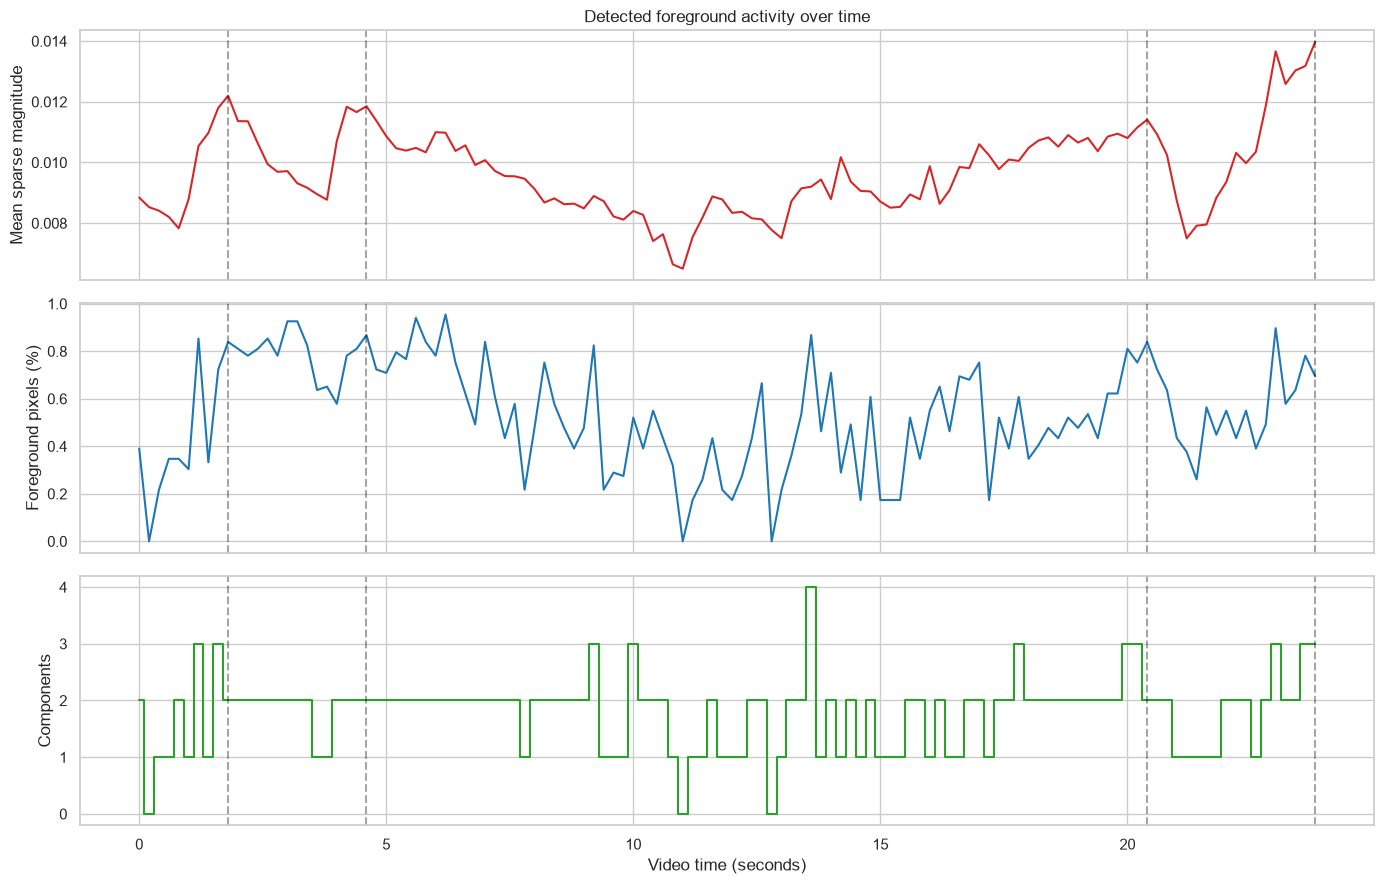

In [14]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 9),
    sharex=True,
)

axes[0].plot(
    motion_df["video_time_seconds"],
    motion_df["motion_strength"],
    color="tab:red",
)

axes[0].set_ylabel("Mean sparse magnitude")
axes[0].set_title("Detected foreground activity over time")

axes[1].plot(
    motion_df["video_time_seconds"],
    100 * motion_df["foreground_fraction"],
    color="tab:blue",
)

axes[1].set_ylabel("Foreground pixels (%)")

axes[2].step(
    motion_df["video_time_seconds"],
    motion_df["detected_components"],
    where="mid",
    color="tab:green",
)

axes[2].set_ylabel("Components")
axes[2].set_xlabel("Video time (seconds)")

for axis in axes:
    for frame_index in selected_frames:
        axis.axvline(
            source_frame_indices[frame_index] / source_fps,
            color="black",
            linestyle="--",
            alpha=0.35,
        )

plt.tight_layout()
plt.show()

In [15]:
default_lambda = 1 / np.sqrt(
    max(video_matrix.shape)
)

lambda_multipliers = [0.7, 1.0, 1.3]

sensitivity_rows = []
sensitivity_results = {
    1.0: (
        low_rank_matrix,
        sparse_matrix,
        convergence_history,
    )
}

for multiplier in lambda_multipliers:
    candidate_lambda = (
        default_lambda * multiplier
    )

    if multiplier == 1.0:
        candidate_low_rank = low_rank_matrix
        candidate_sparse = sparse_matrix
        candidate_history = convergence_history
    else:
        (
            candidate_low_rank,
            candidate_sparse,
            candidate_history,
            _,
        ) = robust_pca(
            video_matrix,
            lambda_value=candidate_lambda,
            tolerance=5e-6,
            verbose=False,
        )

        sensitivity_results[multiplier] = (
            candidate_low_rank,
            candidate_sparse,
            candidate_history,
        )

    singular_values = np.linalg.svd(
        candidate_low_rank,
        compute_uv=False,
    )

    candidate_rank = int(
        np.sum(
            singular_values
            > 0.001 * singular_values[0]
        )
    )

    candidate_error = (
        np.linalg.norm(
            video_matrix
            - candidate_low_rank
            - candidate_sparse,
            ord="fro",
        )
        / np.linalg.norm(video_matrix, ord="fro")
    )

    sensitivity_rows.append({
        "lambda_multiplier": multiplier,
        "lambda": candidate_lambda,
        "effective_rank": candidate_rank,
        "meaningful_sparse_fraction": np.mean(
            np.abs(candidate_sparse) > 0.01
        ),
        "background_temporal_variation": (
            candidate_low_rank
            .std(axis=1)
            .mean()
        ),
        "relative_reconstruction_error": candidate_error,
        "iterations": len(candidate_history),
    })

sensitivity_df = pd.DataFrame(
    sensitivity_rows
).sort_values("lambda_multiplier")

display(sensitivity_df.round(6))

,lambda_multiplier,lambda,effective_rank,meaningful_sparse_fraction,background_temporal_variation,relative_reconstruction_error,iterations
0,0.7,0.008420,5,0.066463,0.006645,0.000005,29
1,1.0,0.012028,9,0.052906,0.007257,0.000001,34
2,1.3,0.015637,12,0.046815,0.007792,0.000003,31


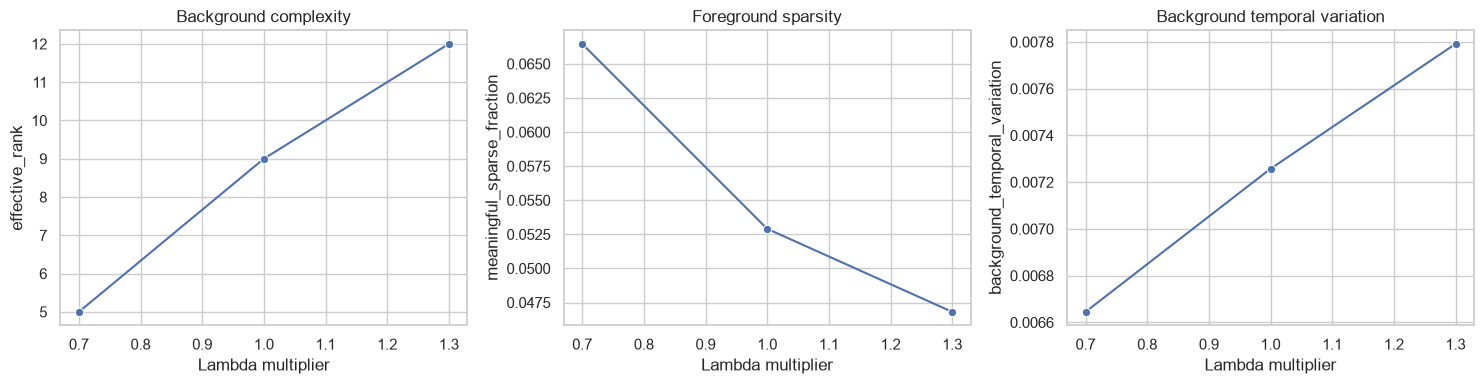

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(
    data=sensitivity_df,
    x="lambda_multiplier",
    y="effective_rank",
    marker="o",
    ax=axes[0],
)

axes[0].set_title("Background complexity")

sns.lineplot(
    data=sensitivity_df,
    x="lambda_multiplier",
    y="meaningful_sparse_fraction",
    marker="o",
    ax=axes[1],
)

axes[1].set_title("Foreground sparsity")

sns.lineplot(
    data=sensitivity_df,
    x="lambda_multiplier",
    y="background_temporal_variation",
    marker="o",
    ax=axes[2],
)

axes[2].set_title("Background temporal variation")

for axis in axes:
    axis.set_xlabel("Lambda multiplier")

plt.tight_layout()
plt.show()

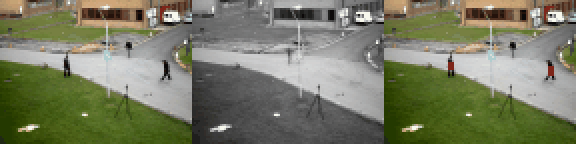

In [17]:
gif_frames = []

for frame_index in range(
    0,
    len(colour_frames),
    2,
):
    original = colour_frames[
        frame_index
    ].copy()

    background_gray = np.clip(
        background_frames[frame_index] * 255,
        0,
        255,
    ).astype(np.uint8)

    background_rgb = cv2.cvtColor(
        background_gray,
        cv2.COLOR_GRAY2RGB,
    )

    overlay = original.copy()

    foreground_pixels = (
        foreground_masks[frame_index] > 0
    )

    overlay[foreground_pixels] = (
        0.35 * overlay[foreground_pixels]
        + 0.65 * np.array([255, 0, 0])
    ).astype(np.uint8)

    combined = np.concatenate(
        [original, background_rgb, overlay],
        axis=1,
    )

    combined = cv2.resize(
        combined,
        None,
        fx=2,
        fy=2,
        interpolation=cv2.INTER_NEAREST,
    )

    gif_frames.append(
        PILImage.fromarray(combined)
    )

GIF_PATH = "robust_pca_foreground_demo.gif"

frame_duration = int(
    1000 * FRAME_STEP * 2 / source_fps
)

gif_frames[0].save(
    GIF_PATH,
    save_all=True,
    append_images=gif_frames[1:],
    duration=frame_duration,
    loop=0,
)

display(Image(filename=GIF_PATH))

## Robust PCA decomposition findings

Robust PCA converged after 34 iterations using the theoretical default lambda value of 0.012028. The relative reconstruction error decreased from approximately 0.115 during the first iteration to 0.00000090 at convergence. Therefore, the final low-rank and sparse components reproduced the original video matrix with almost no unexplained numerical error.

The background had an effective rank of 9, compared with 120 original video frames. This indicates that most of the stable scene could be represented using a small number of important temporal patterns. The optimisation output reported a temporary rank of 63 during the final iteration, but this includes very small retained singular values. The effective rank of 9 counts only singular values larger than 0.1% of the largest singular value, so the two measurements are not contradictory.

Approximately 5.29% of matrix entries had a meaningful sparse magnitude above 0.01. This supports the assumption that foreground activity occupies a relatively small part of the complete video.

The average temporal variation per pixel decreased from 0.031845 in the original video to 0.007257 in the reconstructed background. This represents a 77.21% reduction in temporal variation. The background component was therefore substantially more stable than the original frames.

The visual results show that the low-rank component reconstructed the walkway, grass, buildings and other stationary structures while removing most pedestrians. Some faint pedestrian traces remained, indicating that the separation was strong but not perfect.

The sparse-strength images successfully highlighted the locations and approximate shapes of moving pedestrians. However, the final binary masks were more conservative than the sparse component itself. They frequently captured only the highest-contrast parts of pedestrians, missed some distant or low-contrast people and sometimes fragmented one person into multiple regions. Pedestrians entering or leaving at the image boundary were also only partially detected.

The strongest motion score was 0.0140 at processed frame 119, corresponding to 23.8 seconds. Several of the highest-activity frames occurred between 22.8 and 23.8 seconds. Other clear activity peaks occurred around 1.8 and 4.6 seconds.

Most high-activity frames contained two or three detected connected components. These component counts should not be interpreted directly as pedestrian counts because nearby people may merge into one component, while one pedestrian may be divided into several components.

## Lambda sensitivity findings

The lambda sensitivity analysis produced the expected trade-off between background complexity and foreground sparsity.

With a lambda multiplier of 0.7:

- the effective background rank decreased to 5;
- the meaningful sparse fraction increased to 6.65%;
- background temporal variation decreased to 0.006645;
- convergence required 29 iterations.

The smaller lambda penalised the sparse component less strongly. As a result, more variation was assigned to the foreground and the background became simpler and more stable. However, this setting also has a greater risk of incorrectly treating legitimate background variation as foreground.

With the default lambda:

- the effective rank was 9;
- the meaningful sparse fraction was 5.29%;
- background temporal variation was 0.007257;
- convergence required 34 iterations.

With a lambda multiplier of 1.3:

- the effective rank increased to 12;
- the meaningful sparse fraction decreased to 4.68%;
- background temporal variation increased to 0.007792;
- convergence required 31 iterations.

The larger lambda penalised the sparse component more strongly. Consequently, more temporal variation was absorbed into the background, increasing its rank and making it slightly less stable. This setting may cause moving objects to leak into the background.

All three settings achieved extremely small reconstruction errors between approximately 0.000001 and 0.000005. Reconstruction error alone therefore cannot select the best lambda because each setting can reproduce the input while distributing information differently between the two components.

The results changed gradually and consistently across the tested values, indicating that the main decomposition was reasonably robust to moderate lambda changes. The default lambda provided a sensible balance between a compact background and a sparse foreground. Without labelled foreground masks, however, it is not possible to claim that it is objectively the most accurate setting.

## Final interpretation

Robust PCA successfully represented the stationary surveillance scene as a low-rank component. Only 9 effective temporal components were needed to model 120 frames, and the reconstructed background reduced average temporal variation by 77.21%.

The sparse component mainly corresponded to moving pedestrians. It clearly identified periods and image locations containing foreground activity without using object labels, bounding boxes or segmentation masks. This demonstrates how temporal structure alone can separate moving objects from a stationary scene.

The final binary masks were less complete than the underlying sparse-strength images. High-contrast pedestrians were detected clearly, but some low-contrast, distant or partially visible pedestrians were missed or fragmented. Therefore, the sparse component was more successful as a foreground-activity representation than the binary masks were as precise object segmentations.

The lambda sensitivity experiment showed a stable and interpretable trade-off. Lower lambda values produced simpler backgrounds and larger sparse components, whereas higher values allowed more variation to remain in the background. All settings reconstructed the video accurately, demonstrating why unsupervised model evaluation must consider structure and visual usefulness rather than reconstruction error alone.

The method could be useful for:

- reconstructing an empty background scene;
- identifying periods with unusually high activity;
- producing candidate foreground regions;
- summarising long fixed-camera videos;
- preprocessing footage before object detection or tracking.

It should not yet be treated as a reliable pedestrian counter or safety-monitoring system. Connected components do not correspond exactly to people, and no labelled masks were available to measure segmentation precision, recall or Intersection over Union.

Important limitations include:

- only one fixed-camera video was analysed;
- the processed sequence covered approximately 23.8 seconds;
- frames were heavily downsampled;
- every second frame was retained;
- the method assumes that foreground objects are sparse;
- stationary or slow-moving people may become part of the background;
- lighting changes or camera movement could be mistaken for foreground activity;
- Robust PCA processes the frame matrix as a batch and would need adaptation for continuous real-time video.

Overall, the project demonstrates a successful unsupervised decomposition of video into stable background structure and moving foreground activity. Its strongest result is the interpretable sparse foreground representation, while accurate object-level segmentation would require improved mask post-processing or a supervised detection stage.